<a href="https://colab.research.google.com/github/BarrApcho/Abel-Barrera-Apcho/blob/main/EB_BarreraAcphoAbelAnthonyAndres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PREGUNTA1

1. Escribir un programa que pregunte al usuario por las ventas de un rango de años (unos 4 años) y muestre por pantalla un diagrama de líneas con la evolución de las ventas.

2. Escribir una función que reciba listas y/o diccionario con los nombre y notas de los cursos y devuelva un diagrama de barras de las notas añadiendo las propiedades del gráfico (título, leyenda, títulos de ejes, grid, etiquetas, color de fondo y color de gráfico).

3. Con el ejercicio anterior crea un diagrama de boxplot añadiendo las propiedades del gráfico (, leyenda, títulos de ejes, grid, etiquetas, color de fondo y color de gráfico), así como el título "Distribución de notas".

4. Escribir un código que reciba una serie de Pandas con el número de ventas de un producto durante los meses de un trimestre y cree un diagrama circular con las ventas en formato png con el título “Ventas del primer trimestre” añadiendo las propiedades del gráfico (título, leyenda, etiquetas, color de fondo y color de gráfico). El diagrama debe guardarse en un fichero con formato png y el título dado.

5. El archivo bancos.csv contiene las cotizaciones de los principales bancos con los siguientes campos: Empresa (nombre de la empresa), Apertura (precio de la acción a la apertura de bolsa), Máximo (precio máximo de la acción durante la jornada), Mínimo (precio mínimo de la acción durante la jornada), Cierre (precio de la acción al cierre de bolsa), Volumen (volumen al cierre de bolsa). Filtra unos cuatro bancos luego genera una gráfica de 4 líneas con SEABORN Y FOLIUM añadiendo las propiedades del gráfico (título, leyenda, títulos de ejes, grid, etiquetas, color de fondo y color de gráfico).

6. Usando el archivo anterior realizar merge con el país España y graficar usando geopandas el país de España de este merge añadiendo las propiedades del gráfico (título, leyenda, títulos de ejes, grid, etiquetas, color de fondo y color de gráfico).

In [ ]:
pip install geopandas


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import pandas as pd
import folium

Ingrese el año 1: 2001
Ingrese las ventas del año 2001: 200
Ingrese el año 2: 2002
Ingrese las ventas del año 2002: 240
Ingrese el año 3: 2003
Ingrese las ventas del año 2003: 300
Ingrese el año 4: 2004
Ingrese las ventas del año 2004: 500


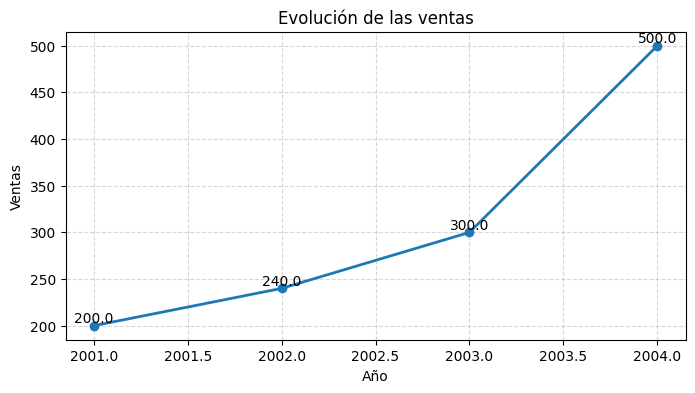

In [ ]:

años = []
ventas = []

for i in range(4):
    año = int(input(f"Ingrese el año {i+1}: "))
    venta = float(input(f"Ingrese las ventas del año {año}: "))
    años.append(año)
    ventas.append(venta)

plt.figure(figsize=(8,4))
plt.plot(años, ventas, marker='o', linewidth=2)
plt.title("Evolución de las ventas")
plt.xlabel("Año")
plt.ylabel("Ventas")
plt.grid(True, linestyle="--", alpha=0.5)

for x,y in zip(años, ventas):
    plt.text(x, y, y, ha='center', va='bottom')

plt.show()


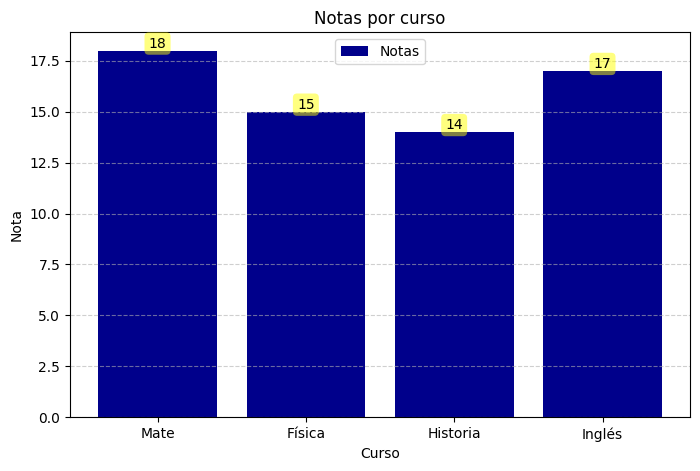

In [ ]:
def barras_notas(datos, background_color='white', bar_color='darkblue'):
    serie = pd.Series(datos)

    fig, ax = plt.subplots(figsize=(8,5))
    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)

    ax.bar(serie.index, serie.values, color=bar_color)
    ax.set_title("Notas por curso")
    ax.set_xlabel("Curso")
    ax.set_ylabel("Nota")
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(["Notas"])

    for i,v in enumerate(serie.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc='yellow', ec='b', lw=0, alpha=0.5))

    plt.show()

# Ejemplo de uso:
barras_notas({"Mate":18, "Física":15, "Historia":14, "Inglés":17})

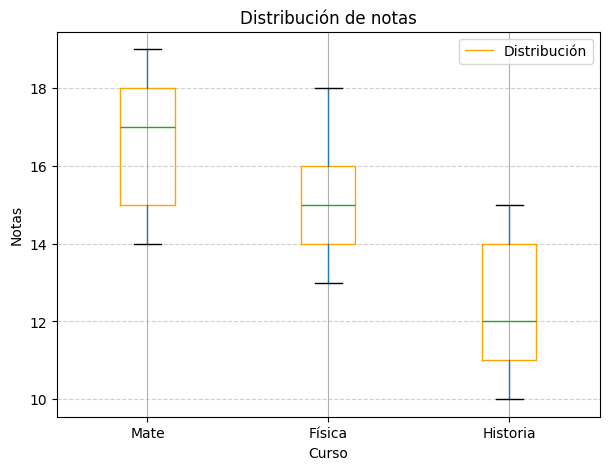

In [ ]:
def boxplot_notas(datos,background_color='white', box_color='orange'):
    df = pd.DataFrame(dict([(k,pd.Series(v)) for k,v in datos.items()]))

    fig, ax = plt.subplots(figsize=(7,5))
    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)
    df.boxplot(ax=ax, boxprops=dict(color=box_color))
    ax.set_title("Distribución de notas")
    ax.set_xlabel("Curso")
    ax.set_ylabel("Notas")
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(["Distribución"])

    plt.show()

# Ejemplo
boxplot_notas({
    "Mate":[18,15,14,19,17],
    "Física":[14,15,16,13,18],
    "Historia":[12,10,14,11,15]
})

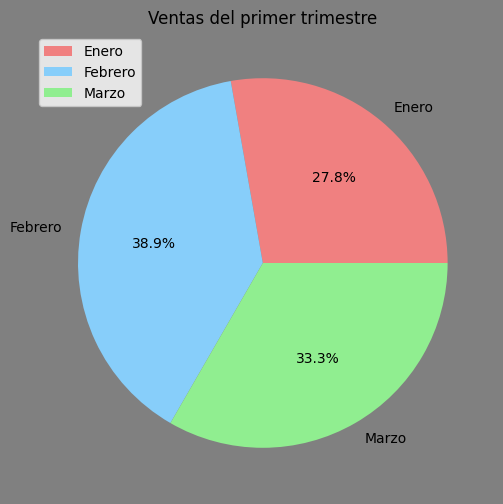

Archivo guardado como: Ventas_del_primer_trimestre.png


In [ ]:
def circular_trimestre(serie, background_color='grey', pie_colors=None , nombre="Ventas_del_primer_trimestre.png"):
    fig, ax = plt.subplots(figsize=(6,6))
    fig.patch.set_facecolor(background_color)

    if pie_colors is None:
        pie_colors = ['lightcoral', 'lightskyblue', 'lightgreen']

    ax.pie(serie.values, labels=serie.index, autopct="%1.1f%%", colors=pie_colors)
    ax.set_title("Ventas del primer trimestre")
    ax.legend(serie.index)
    plt.savefig(nombre, dpi=300)
    plt.show()

    print("Archivo guardado como:", nombre)

# Ejemplo
s = pd.Series([5000, 7000, 6000], index=["Enero", "Febrero", "Marzo"])
circular_trimestre(s)

In [ ]:
df = pd.read_csv("bancos.csv")

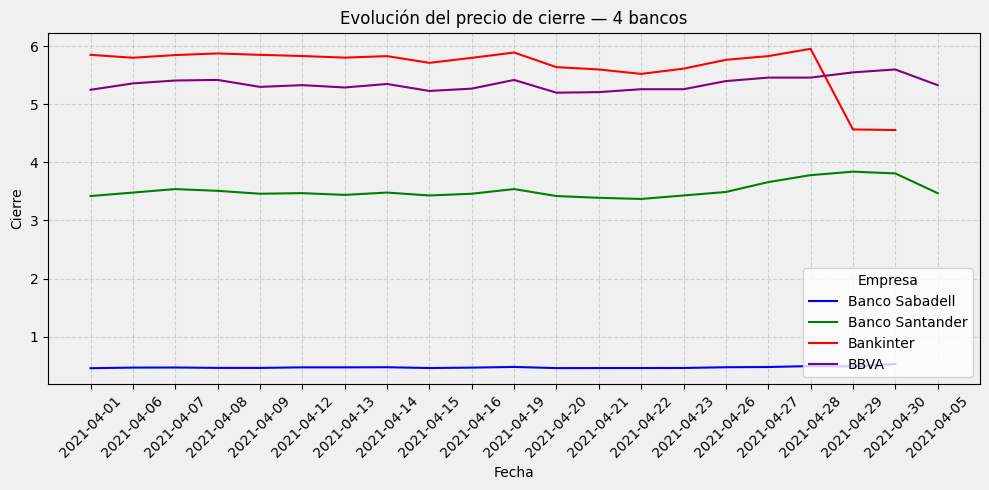

In [ ]:
# Elegimos 4 bancos
bancos = df["Empresa"].unique()[:4]
df4 = df[df["Empresa"].isin(bancos)]

def plot_bank_evolution(data, background_color=None, line_palette=None):
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)

    sns.lineplot(data=data, x="Fecha", y="Cierre", hue="Empresa", palette=line_palette, ax=ax)
    ax.set_title("Evolución del precio de cierre — 4 bancos")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Cierre")
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Llamada a la función para mostrar el gráfico
plot_bank_evolution(df4, background_color='#f0f0f0', line_palette=['blue', 'green', 'red', 'purple'])

In [ ]:
url_mexico="https://raw.githubusercontent.com/angelnmara/geojson/refs/heads/master/mexicoHigh.json"
df_mexico=gpd.read_file(url_mexico)

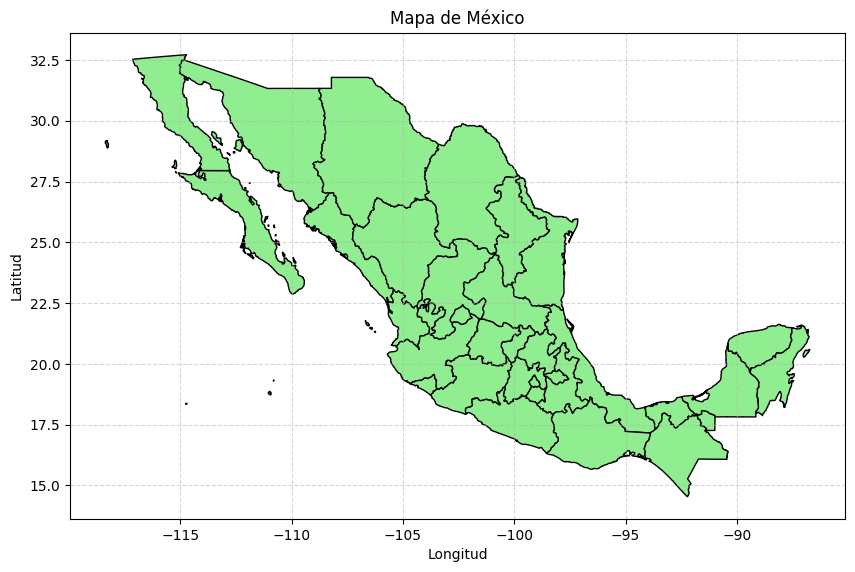

In [ ]:
# URL del GeoJSON de México
url_mexico="https://raw.githubusercontent.com/angelnmara/geojson/refs/heads/master/mexicoHigh.json"
df_mexico=gpd.read_file(url_mexico)

# Graficar México
fig, ax = plt.subplots(figsize=(10,8))
df_mexico.plot(ax=ax, color="lightgreen", edgecolor="black")

plt.title("Mapa de México")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

In [ ]:
# 1. Crear un DataFrame para el país España
pais = pd.DataFrame({"Empresa": df["Empresa"].unique(), "Pais": "Mexico"})

# 2. Realizar el merge con los datos de los bancos
merge_df_mex = pd.merge(df, pais, on="Empresa", how="left")

print("Merge realizado con éxito. Primeras filas del DataFrame fusionado:")
print(merge_df_mex.head())

Merge realizado con éxito. Primeras filas del DataFrame fusionado:
          Empresa       Fecha  Apertura  Máximo  Mínimo  Cierre   Volumen  \
0  Banco Sabadell  2021-04-01    0.4591  0.4591  0.4445  0.4553  30084389   
1  Banco Sabadell  2021-04-06    0.4630  0.4778  0.4581  0.4656  44336977   
2  Banco Sabadell  2021-04-07    0.4650  0.4705  0.4626  0.4673  22517116   
3  Banco Sabadell  2021-04-08    0.4662  0.4695  0.4536  0.4607  30800345   
4  Banco Sabadell  2021-04-09    0.4607  0.4644  0.4512  0.4600  35703383   

     Pais  
0  Mexico  
1  Mexico  
2  Mexico  
3  Mexico  
4  Mexico  


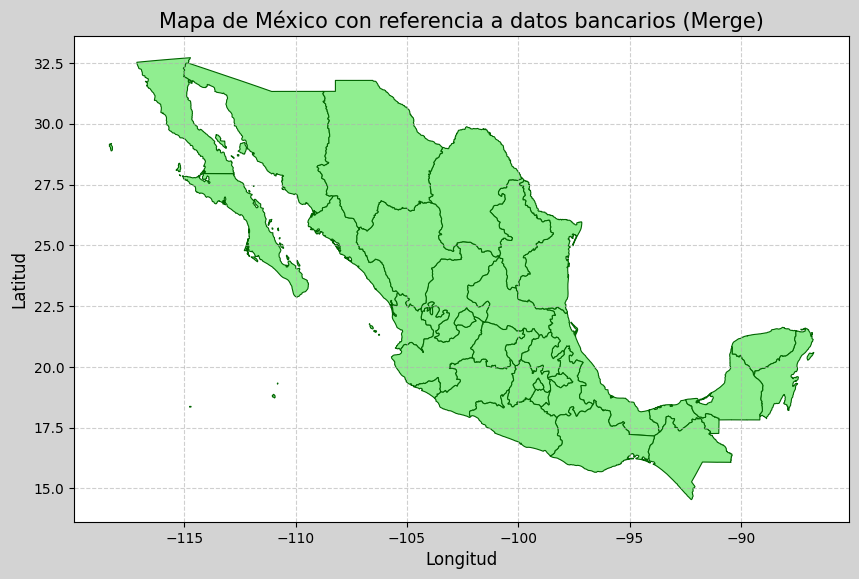

In [ ]:
# Graficar México con propiedades y referencia al merge
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
fig.patch.set_facecolor('lightgrey') # Color de fondo del gráfico
ax.set_facecolor('white') # Color de fondo del área del mapa

df_mexico.plot(ax=ax, color='lightgreen', edgecolor='darkgreen', linewidth=0.8)

ax.set_title("Mapa de México con referencia a datos bancarios (Merge)", fontsize=15)
ax.set_xlabel("Longitud", fontsize=12)
ax.set_ylabel("Latitud", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Si merge_df_mex tuviera información que se pudiera mapear (e.g., puntos de interés),
# se podría añadir aquí, pero por ahora solo se menciona en el título.

plt.show()